In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.autograd.functional import hessian
import torch.optim as optim


In [2]:
def plotUnc(iX,iY,iPars,iModel,iH_inv,iPlot=True,iColor="r"):
    # Test inputs
    x_out_sort,sort = torch.sort(iX,axis=0)
    y_in_sort  = iY[sort]
    y_out_sort = iModel(x_out_sort,iPars).detach().numpy()
    y_pred_std = []

    for x in x_out_sort:
        # Define scalar output function at this x
        def f(p):
            return iModel(x.unsqueeze(0), p).squeeze()

        # Compute gradient w.r.t. parameters
        grad_fx = torch.autograd.grad(f(iPars), iPars, retain_graph=True)[0].unsqueeze(0)
        var_fx = grad_fx @ iH_inv @ grad_fx.T
        std_fx = torch.sqrt(var_fx).item()
        y_pred_std.append(std_fx)

    y_pred_std = np.array(y_pred_std)

    # Plot
    if iPlot:
        #plt.figure(figsize=(8,6))
        plt.plot(iX.numpy(), iY.numpy(), 'bo', label="Training Data")
        plt.plot(x_out_sort.numpy(), y_out_sort, color=iColor, label="Mean Prediction")
        plt.fill_between(x_out_sort.numpy().flatten(),
                         y_out_sort.flatten() - y_pred_std,
                         y_out_sort.flatten() + y_pred_std,
                         color=iColor, alpha=0.3, label="Uncertainty (1σ)")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.legend()
        #plt.show()
        
        #resid=(iY.numpy()-y_out_sort)
        #plt.hist(resid)
        #plt.show()
        #print("mean:",resid.mean(),"+/-",resid.std())        
        
    return x_out_sort,y_out_sort,y_pred_std,y_in_sort
    

In [15]:
def solve_trust_region1(H, g, delta):
    eigvals, eigvecs = torch.linalg.eigh(H)
    g_proj = eigvecs.T @ g

    # Unconstrained step
    d = torch.zeros_like(g_proj)
    for i in range(len(eigvals)):
        if eigvals[i] > 1e-8:
            d[i] = -g_proj[i] / eigvals[i]
    p = eigvecs @ d

    if torch.norm(p) <= delta:
        return p  # Accept full step

    # Constrained step (projected)
    d_scaled = -g_proj / (eigvals + 1e-4)  # Avoid division by near-zero
    p_proj = eigvecs @ d_scaled
    return p_proj * (delta / torch.norm(p_proj))

# Solve the trust-region subproblem: minimize 0.5 x^T H x + g^T x s.t. ||x|| <= delta
def solve_trust_region2(H, g, delta):
    # Use torch.linalg.solve or SVD depending on conditioning
    try:
        # Eigen-decomposition for trust-region solution
        eigvals, eigvecs = torch.linalg.eigh(H)
        g_proj = eigvecs.T @ g
        d = torch.zeros_like(g)

        # Steihaug-type approach
        for i in range(len(eigvals)):
            if eigvals[i] > 1e-8:
                d[i] = -g_proj[i] / eigvals[i]
            else:
                d[i] = 0.0

        p = eigvecs @ d
        if torch.norm(p) <= delta:
            return p  # Full step is inside trust region

        # Otherwise, project onto trust region boundary
        # Tau solution: scaled direction
        p = eigvecs @ (-g_proj / (eigvals + 1e-6))  # Small ridge
        return p * (delta / torch.norm(p))

    except RuntimeError:
        print("Warning: fallback to gradient step due to Hessian issues.")
        return -g * (delta / torch.norm(g))

# Hessian-vector product
def hvp(grad, model, v, pars):
    hv = torch.autograd.grad(grad, pars, grad_outputs=v, retain_graph=True)
    return torch.cat([h.contiguous().view(-1) for h in hv])

# Flatten model parameters
def get_flat_params(model):
    return torch.cat([p.data.view(-1) for p in model.parameters()])

def set_flat_params(model, flat_params):
    idx = 0
    for p in model.parameters():
        numel = p.numel()
        p.data.copy_(flat_params[idx:idx+numel].view(p.shape))
        idx += numel

# Get gradient as flat vector
def get_flat_grad(model, loss):
    grads = torch.autograd.grad(loss, model.parameters(), create_graph=True)
    return torch.cat([g.contiguous().view(-1) for g in grads])

# Compute tau for trust region boundary
def solve_trust_boundary(x, p, delta):
    a = torch.dot(p, p)
    b = 2 * torch.dot(x, p)
    c = torch.dot(x, x) - delta**2
    tau = (-b + torch.sqrt(b**2 - 4*a*c)) / (2*a)
    return tau

# Truncated Conjugate Gradient for Trust Region
def truncated_cg(grad, hvp_func, trust_radius, pars, max_iter=50):
    x = torch.zeros_like(grad)
    r = -grad.clone()
    p = r.clone()
    rs_old = torch.dot(r, r)

    for i in range(max_iter):
        Hp = hvp_func(p)
        alpha = rs_old / (torch.dot(p, Hp) + 1e-10)

        x_new = x + alpha * p

        if torch.norm(x_new) > trust_radius:
            # Step hits the boundary of the trust region
            tau = solve_trust_boundary(x, p, trust_radius)
            return x + tau * p

        x = x_new
        r = r - alpha * Hp
        rs_new = torch.dot(r, r)
        if rs_new.sqrt() < 1e-8:
            break
        p = r + (rs_new / rs_old) * p
        rs_old = rs_new
    return x

def train(iX,iY,iNEpoch,iModel,iParams,iLoss,dampingconst=1e-3):
    def closure(p):
        y_pred = iModel(iX, p)
        return iLoss(y_pred, iY, p)
    H_damped = 0
    #pars=iParams.clone()
    delta=1.0
    dampingconst0=dampingconst
    for epoch in range(iNEpoch):
        # Compute gradient
        loss = closure(iParams)
        grad = torch.autograd.grad(loss, iParams, create_graph=True)[0]

        # Compute Hessian
        #H = hessian(closure, iParams)
        # Damping for stability
        #damping = dampingconst0 * torch.eye(H.shape[0])
        #H_damped = H + damping

        #newton-cg
        def hv_func(v):
            return hvp(grad, iModel, v, iParams)
        step = truncated_cg(grad, hv_func, delta, iParams)
        iParams = iParams + step*dampingconst
        
        #trust step
        #step = solve_trust_region2(H_damped, grad, delta)
        #pars = pars - step
        
        # Newton step
        #delta = -torch.linalg.solve(H_damped, grad.detach())
        #iParams = (iParams.detach() + delta).requires_grad_()
        
        new_loss = closure(iParams)
        if loss.item()-new_loss.item() > 0:
            delta *= 1.5  # Increase trust radius
            dampingconst0 *= 0.8  # Reduce damping
        else:
            delta *= 0.5  # Shrink trust radius
            dampingconst0 *= 1.5  # Increase damping
        
        if epoch % 25 == 0:
            print(f"Epoch {epoch+1}: Loss = {closure(iParams).item():.4f}")
    def closuref(p):
        y_pred = iModel(iX, p)
        return iLoss(y_pred, iY, [])
    H_final = hessian(closuref, iParams)
    return H_final,iParams

def train_basic(iX,iY,iNEpoch,iModel,iParams,iLoss,dampingconst=1e-3):
    #pars=iParams.clone()
    optimizer = optim.Adam([iParams], lr=1e-2)
    for epoch in range(iNEpoch):
        optimizer.zero_grad()
        y_pred = iModel(iX, iParams)
        loss   = iLoss(y_pred, iY, iParams)
        loss.backward()
        optimizer.step()
        if epoch % 500 == 0:
            print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}")
    def closuref(p):
        y_pred = iModel(iX, p)
        return iLoss(y_pred, iY, [])
    H_final = hessian(closuref, iParams)
    return H_final,iParams

# Trust-Region Newton step
def trust_region_newton_step(iModel, iX, iY, iLoss, dampingconst=1e-3, trust_radius=1.0):
    output = iModel(iX)
    loss = iLoss(output, y)
    grad = get_flat_grad(model, loss)

    def hv_func(v):
        return hvp(grad, model, v)

    step = truncated_cg(grad, hv_func, trust_radius)
    old_params = get_flat_params(model)
    set_flat_params(model, old_params + step)
    return loss.item()

# Generate simple training data
def train2(iX,iY,iNEpoch,iModel,iParams,iLoss,dampingconst=1e-3,trust_radius=1.0):
    # Training loop
    for i in range(iNEpoch):
        loss = trust_region_newton_step(iModel, iX, iY, iLoss,dampingconst=dampingconst,trust_radius=trust_radius)
        print(f"Iteration {i+1}, Loss: {loss:.6f}")
    

In [4]:
# Define a simple neural network (functional form)
class SimpleNN(nn.Module):
    def __init__(self,nhidden=10,nlayers=2):
        super(SimpleNN, self).__init__()
        self.shapes = []#[ (1,nhidden), (nhidden,), (nhidden,1), (1,) ]  # Layer shapes
        self.shapes.append((1,nhidden))
        self.shapes.append((nhidden,))
        for pVal in range(nlayers-2):
            self.shapes.append((nhidden,nhidden))
            self.shapes.append((nhidden,))
        self.shapes.append((nhidden,1))
        self.shapes.append((1,))
        self.nhidden = nhidden
        self.nlayers = nlayers
        self.total_params = sum([torch.tensor(s).prod() for s in self.shapes])
        self.act     = torch.nn.SiLU()
        #self.act     = torch.nn.ReLU()
        #self.act     = torch.nn.GELU()
    
    def forward(self, x, params):
        idx = 0
        W1 = params[idx:idx+1*self.nhidden].reshape(1,self.nhidden)
        idx += 1*self.nhidden
        b1 = params[idx:idx+self.nhidden].reshape(self.nhidden)
        idx += self.nhidden
        x    =  self.act(x @ W1 + b1) 
        for pVal in range(self.nlayers-2):
            Wx   =  params[idx:idx+self.nhidden*self.nhidden].reshape(self.nhidden,self.nhidden)
            idx  += self.nhidden*self.nhidden
            bx   =  params[idx:idx+self.nhidden*1].reshape(self.nhidden)
            idx  += self.nhidden
            x    =  self.act(x @ Wx + bx)    
        W2 = params[idx:idx+self.nhidden*1].reshape(self.nhidden,1)
        idx += self.nhidden*1
        b2 = params[idx:idx+1].reshape(1)
        x = x @ W2 + b2
        return x

# Simple MLP
class SimpleNet(nn.Module):
    def __init__(self,nhidden=10,nlayers=2):
        super().__init__()
        self.act = torch.nn.SiLU()
        self.arr = []
        self.arr.append(nn.Linear(1,nhidden))
        self.arr.append(self.act)
        for pLayer in range(nlayers-2):
            self.arr.append(nn.Linear(nhidden,nhidden))
            self.arr.append(self.act)
        self.arr.append(nn.Linear(nhidden,1))
        self.arr.append(self.act)
        self.net = nn.Sequential(
            *self.arr
        )

    def forward(self, x):
        return self.net(x)

    
    
class quadrat(nn.Module):
    def __init__(self,npars=3):
        super(quadrat, self).__init__()
        self.shapes = [ (npars,) ]  # Layer shapes
        self.total_params = sum([torch.tensor(s).prod() for s in self.shapes])
        self.npars = npars
    
    def forward(self, x, params):
        x1 = params[0] + params[1]*x + params[2]*(x**2)
        if self.npars > 3:
            x1 += params[3]*(x**3)
        if self.npars > 4:
            x1 += params[4]*(x**4)
        if self.npars > 5:
            x1 += params[5]*(x**4)
        return x1
    

class LogLikeLoss(nn.Module):
    def __init__(self,sigma=1,l2reg=1e-3):
        super(LogLikeLoss, self).__init__()
        self.sigma = sigma
        self.l2reg = l2reg
        
    def forward(self, y_pred, y_true,params=0):
        squared_difference = ((1./self.sigma)**2)*(y_true - y_pred)**2
        loss = torch.mean(squared_difference)
        if len(params) > 0:
            loss += self.l2reg*torch.sum(params**2) 
        return loss
    

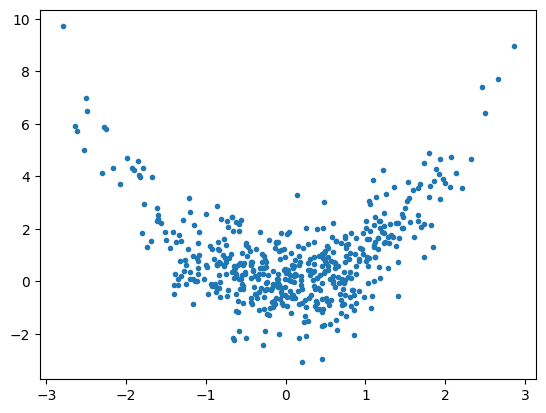

In [38]:
# Generate data
#torch.manual_seed(42)
x_train = torch.randn(500,1)
y_train = x_train**2 +  torch.randn(500,1)
plt.plot(x_train,y_train,'.')


Epoch 1: Loss = 1.0458
Epoch 26: Loss = 1.0458
Epoch 51: Loss = 1.0458
Epoch 1: Loss = 2.7543
Epoch 501: Loss = 1.0480


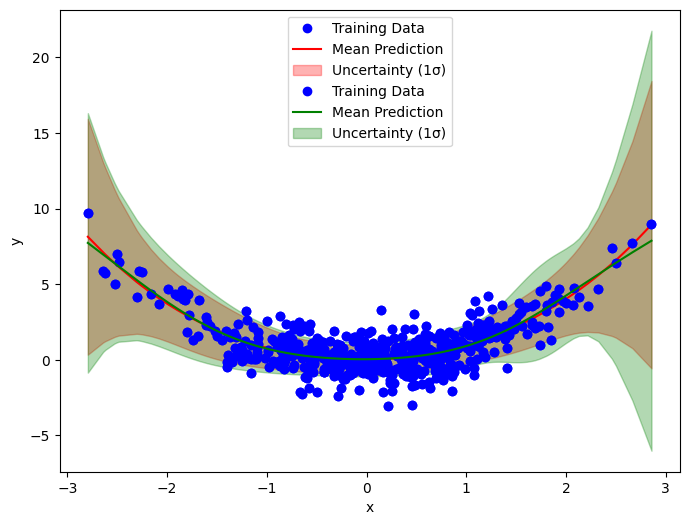

tensor([[ 1.4264e+02, -2.4750e+00, -2.3161e+01, -4.2872e+01, -2.2784e+00,
          2.0425e+01,  1.2576e+02, -8.6028e+00, -1.8322e+02,  7.7811e+00,
         -1.1207e+01,  1.6863e+02,  7.4974e+01,  1.8403e+01, -8.8245e+01,
          1.2887e+02, -7.9812e+01, -7.7510e+01,  3.6375e+01,  8.4692e+01,
         -4.5395e+01,  2.5101e+02],
        [-2.4436e+00,  2.8306e+01, -1.5491e+01, -2.0252e+01, -8.9415e+01,
         -1.1698e+01,  1.1445e+01, -1.2898e+00,  3.7316e+01, -2.5203e+02,
         -2.7555e+01,  5.9899e+01,  8.5783e+01,  1.8994e+00, -5.3518e+01,
         -4.2142e+01, -1.2281e+01,  1.0291e+02, -1.1348e+02, -1.9572e+01,
         -2.7884e+01, -1.8461e+01],
        [-2.3104e+01, -1.5403e+01,  3.0414e+01,  3.9270e+00,  3.6712e+01,
         -8.7237e+00,  2.3270e+01, -1.4486e+01, -1.4333e+01, -6.2935e+01,
          1.0058e+02, -1.4850e+03,  2.6503e+01, -9.9683e-01,  6.8208e+01,
         -2.2414e+02,  8.2930e+01, -3.6459e+02, -4.0745e+02, -2.3124e+02,
          5.0518e+01, -1.5778e+02],
    

In [102]:
model1 = quadrat(npars=5)
model2 = SimpleNN(nhidden=3,nlayers=3)
params1= torch.randn(model1.total_params, requires_grad=True)
params2 = torch.randn(model2.total_params, requires_grad=True)
loss_fn = LogLikeLoss(sigma=1.,l2reg=1e-6)
H1_out,pars1_out=train(x_train,y_train,51,model1,params1,loss_fn,dampingconst=1e0)
H2_out,pars2_out=train_basic(x_train,y_train,501,model2,params2,loss_fn,dampingconst=1e0)
#x_out_sort = torch.sort(x_train,axis=0)[0]
#y_out_sort = model(x_out_sort,pars_out).detach().numpy()
#plt.plot(x_train,y_train,'.')
#plt.plot(x_out_sort,y_out_sort,'--',c='r')
#print(torch.sort(pars2_out)[0][0:10])

H1_inv = torch.linalg.inv(H1_out).detach()
H2_inv = torch.linalg.inv(H2_out).detach()
#print(H_inv,pars_out)
#eigv,eigvec=np.linalg.eig(H_inv)
#print(eigv,eigv)
plt.figure(figsize=(8,6))
x1_out,y1_out,y1_std,y1_in = plotUnc(x_train,y_train,pars1_out,model1,H1_inv)
x2_out,y2_out,y2_std,y2_in = plotUnc(x_train,y_train,pars2_out,model2,H2_inv,iColor='green')
plt.show()

print(H2_inv)

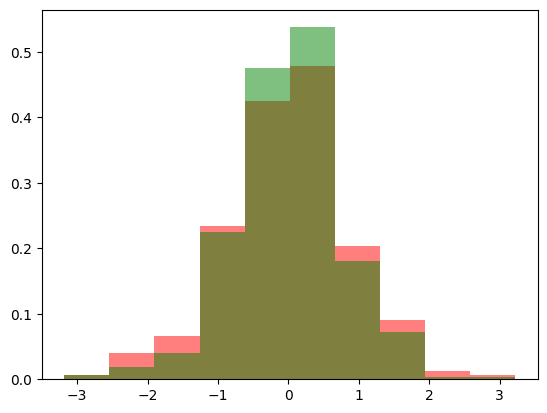

check fit resid1: 7.737709597417109e-05 0.8866214226237568
check fit resid2: 0.002854278064111188 0.748863491416633


In [104]:
diff1=(y1_in.flatten()-y1_out.flatten())/y1_std
diff2=(y2_in.flatten()-y2_out.flatten())/y2_std
#print(diff2[20:100])#,y1_in[20:70],y2_out[20:70],y2_std[20:70])
#a
#diff2=diff2[diff2 > -5]
_,bins,_=plt.hist(diff1,alpha=0.5,color='red',density=True)
_,bins,_=plt.hist(diff2,bins=bins,alpha=0.5,color='green',density=True)
plt.show()
print("check fit resid1:",diff1.numpy().mean(),diff1.numpy().std())
print("check fit resid2:",diff2.numpy().mean(),diff2.numpy().std())

In [96]:
def printUnc(iXsort,iPars,iModel,iH_inv):
    # Test inputs
    #y_out_sort = iModel(iXsort,iPars).detach().numpy()
    y_pred_std = []

    for x in iXsort:
        # Define scalar output function at this x
        def f(p):
            return iModel(x.unsqueeze(0), p).squeeze()

        # Compute gradient w.r.t. parameters
        grad_fx = torch.autograd.grad(f(iPars), iPars, retain_graph=True)[0].unsqueeze(0)
        var_fx      = grad_fx @ iH_inv @ grad_fx.T
        var_fx_diag = grad_fx @ (iH_inv*torch.eye(iH_inv.shape[0])) @ grad_fx.T
        std_fx = torch.sqrt(var_fx).item()
        print(var_fx_diag,var_fx)
        #print("check",std_fx,var_fx,grad_fx,f(iPars),"!!")
printUnc(x2_out[50:100],pars2_out,model2,H2_inv)
#print(torch.eye(H2_inv.shape[0]))

tensor([[16.5757]]) tensor([[0.4895]])
tensor([[15.4232]]) tensor([[0.4480]])
tensor([[7.1989]]) tensor([[0.1561]])
tensor([[6.6254]]) tensor([[0.1362]])
tensor([[6.3580]]) tensor([[0.1269]])
tensor([[3.2354]]) tensor([[0.0196]])
tensor([[0.4096]]) tensor([[-0.0752]])
tensor([[-3.2031]]) tensor([[-0.1926]])
tensor([[-4.7112]]) tensor([[-0.2402]])
tensor([[-5.8316]]) tensor([[-0.2749]])
tensor([[-6.5248]]) tensor([[-0.2960]])
tensor([[-6.7060]]) tensor([[-0.3015]])
tensor([[-7.3303]]) tensor([[-0.3203]])
tensor([[-7.8172]]) tensor([[-0.3349]])
tensor([[-8.3028]]) tensor([[-0.3492]])
tensor([[-21.2614]]) tensor([[-0.6745]])
tensor([[-25.7577]]) tensor([[-0.7526]])
tensor([[-27.0340]]) tensor([[-0.7704]])
tensor([[-27.2462]]) tensor([[-0.7732]])
tensor([[-29.7156]]) tensor([[-0.8011]])
tensor([[-34.9789]]) tensor([[-0.8300]])
tensor([[-36.9522]]) tensor([[-0.8286]])
tensor([[-38.3518]]) tensor([[-0.8231]])
tensor([[-38.7727]]) tensor([[-0.8207]])
tensor([[-42.0123]]) tensor([[-0.7891]])
t